In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

In [119]:
df_train = pd.read_csv("../data/housing/train.csv")
df_test = pd.read_csv("../data/housing/test.csv")

df_train_syn = pd.read_csv('../syn_data_samples/housing/tabscm/sample1.csv')

In [4]:
import shap
import sklearn
import xgboost

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

/home/sven/miniconda3/envs/XAI-TS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [120]:
X_train = df_train.iloc[:1000,:-1]
y_train = df_train.iloc[:1000,-1]

X100 = df_test.iloc[:100,:-1]


model_real = xgboost.XGBRegressor()
model_real.fit(X_train, y_train)


X_train_syn = df_train_syn.iloc[:1000,:-1]
y_train_syn = df_train_syn.iloc[:1000,-1]

model_real_syn = xgboost.XGBRegressor()
model_real_syn.fit(X_train_syn, y_train_syn)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,1.9038,34.0,2.341232,1.134597,2326.0,2.204739,34.06,-118.31
1,4.1047,52.0,3.935484,1.052109,1259.0,1.562035,37.80,-122.43
2,2.5921,20.0,6.024221,1.145329,1466.0,5.072664,36.52,-119.73
3,3.2010,44.0,4.366721,1.071082,1045.0,1.688207,34.07,-118.37
4,3.1312,19.0,4.137724,1.143712,324.0,1.940120,36.91,-122.01
...,...,...,...,...,...,...,...,...
95,2.4233,5.0,4.361111,0.888889,880.0,3.055556,33.69,-117.81
96,6.5410,21.0,7.202439,1.021951,1397.0,3.407317,34.16,-118.95
97,3.6346,39.0,5.177993,1.114887,1391.0,2.250809,37.76,-122.47
98,6.8300,28.0,6.748743,1.080402,487.0,2.447236,34.05,-118.78


In [245]:
for i ,col in enumerate(df_train.columns):
    print(i,col)

0 MedInc
1 HouseAge
2 AveRooms
3 AveBedrms
4 Population
5 AveOccup
6 Latitude
7 Longitude
8 MedHouseVal


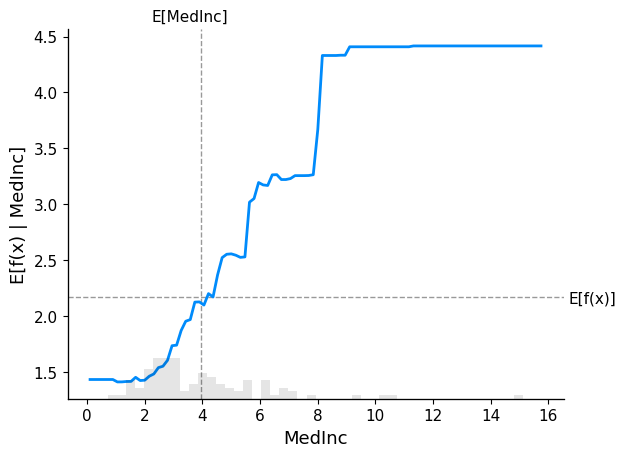

In [112]:
shap.partial_dependence_plot(
    "MedInc",
    model_real.predict,
    X100,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

In [121]:
# compute the SHAP values for the linear model
explainer = shap.Explainer(model_real.predict, X100)
shap_values = explainer(X_train)

explainer_syn = shap.ExactExplainer(model_real_syn.predict,X100)
shap_values_syn = explainer_syn(X_train_syn)

ExactExplainer explainer: 1001it [00:14, 12.88it/s]                         
ExactExplainer explainer: 1001it [00:11, 15.67it/s]                          


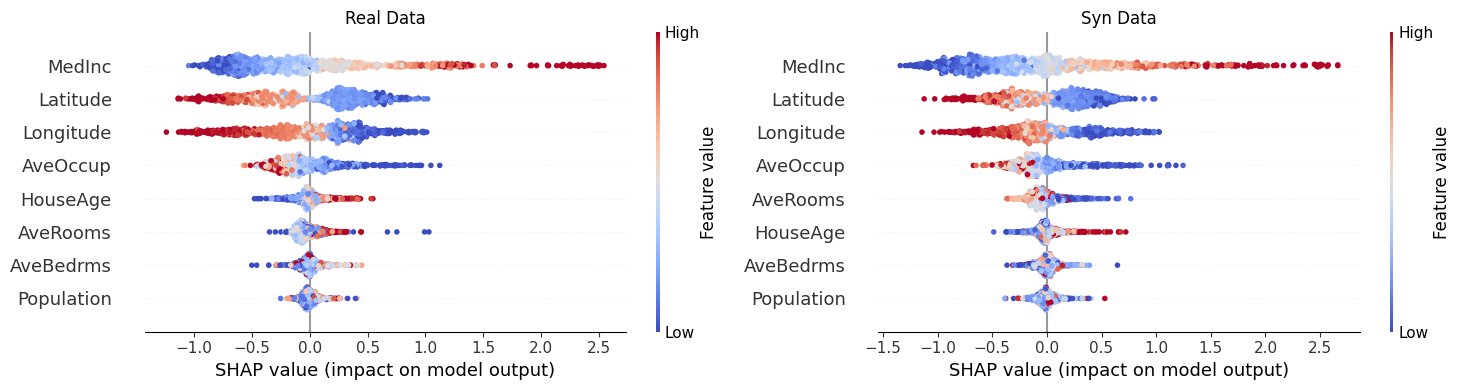

In [249]:
# fig, ax = plt.subplots(1,2)
# plt.sca(ax[0])
# shap.plots.beeswarm(shap_values)# order=shap_values.abs.max(0))

# #plt.sca(ax[1])
# shap.plots.beeswarm(shap_values_syn,show=False,ax=ax[1],plot_size=None)

# fig.tight_layout()
import matplotlib.pyplot as plt
import shap

# 1. Initialize the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

# 2. Plot first beeswarm
plt.sca(ax1) # Set Current Axis to ax1
shap.plots.beeswarm(shap_values, show=False, plot_size=None,color=plt.get_cmap('coolwarm'))
plt.title("Real Data")

# 3. Plot second beeswarm
plt.sca(ax2) # Set Current Axis to ax2
shap.plots.beeswarm(shap_values_syn, show=False, plot_size=None,color=plt.get_cmap('coolwarm'))
plt.title("Syn Data")

# 4. Final touches
plt.tight_layout()
plt.show()

In [251]:
fig.savefig('Shape_alignment.pdf',bbox_inches='tight')

In [157]:
from pathlib import Path
import sys

# Move up one level from the current file's directory
path_root = Path.cwd().parent
sys.path.append(str(path_root))

from tabscm.sample_utils import *

In [162]:
#### load scm for housing data

exp_save =  f'./models/housing'
exp_save = "/home/sven/coding/python/TabSCM/tabscm/models/housing"#scm/default_scm_meta.json
loaded_scm = load_scm(f'{exp_save}/scm',device='cuda')

/home/sven/miniconda3/envs/XAI-TS/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KernelDensity from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/sven/miniconda3/envs/XAI-TS/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [186]:
X_PA = X_train[['MedInc','AveOccup']]

with open(f"/home/sven/coding/python/TabSCM/data/housing/info.json") as f:
        INFO = json.load(f)

In [181]:
diffusion_model = loaded_scm[8][0]

In [192]:
def process(df,info,name):

    data = df.copy()
    cols_to_encode = info['cat_col_idx'].copy()

    if info['task_type'] != 'regression':
        cols_to_encode.append(info['target_col_idx'][0])
    

    
    N_CLASSES = {i: int(df[c].max()+1) for i,c in enumerate(df.columns)}
    info['col_dtype'] = {i: df.dtypes[i] for i in info['num_col_idx']}
    info['n_classes'] = N_CLASSES
    info['col_dtype'][info['target_col_idx'][0]] = df.dtypes[info['target_col_idx'][0]]



    return _,info

_,info = process(df_train,INFO,_)

/tmp/ipykernel_1870/3906362990.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  info['col_dtype'] = {i: df.dtypes[i] for i in info['num_col_idx']}
/tmp/ipykernel_1870/3906362990.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  info['col_dtype'] = {i: df.dtypes[i] for i in info['num_col_idx']}
/tmp/ipykernel_1870/3906362990.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  info['col_dtype'] = {i: df.dtypes[i] for i in info

In [237]:
class diff_model():
    def __init__(self,diffusion_model,node,info):
        #self.X = X
        self.model = diffusion_model
        self.node = node
        self.info = info
    def predict(self,X):
        return self.model.predict(X,self.node,self.info)
    

model_diff = diff_model(diffusion_model=diffusion_model,node=8,info=info)

In [194]:
predictions = diffusion_model.predict(X_PA,8,info)

In [239]:
X100_PA = X100[['MedInc','AveOccup']]

explainer_f = shap.Explainer(model_diff.predict, X100_PA)
shap_values_f = explainer_f(X_PA)

ExactExplainer explainer:   5%|▍         | 49/1000 [00:43<13:34,  1.17it/s]/home/sven/coding/python/TabSCM/tabscm/diffusion_regressor.py:220: RuntimeWarning: overflow encountered in exp
  y_sigmoid = 1 / (1 + np.exp(-y_np))  # sigmoid
ExactExplainer explainer:  29%|██▉       | 292/1000 [04:32<11:47,  1.00it/s]/home/sven/coding/python/TabSCM/tabscm/diffusion_regressor.py:220: RuntimeWarning: overflow encountered in exp
  y_sigmoid = 1 / (1 + np.exp(-y_np))  # sigmoid
ExactExplainer explainer:  35%|███▌      | 350/1000 [06:23<24:06,  2.23s/it]/home/sven/coding/python/TabSCM/tabscm/diffusion_regressor.py:220: RuntimeWarning: overflow encountered in exp
  y_sigmoid = 1 / (1 + np.exp(-y_np))  # sigmoid
ExactExplainer explainer:  36%|███▌      | 357/1000 [06:38<22:41,  2.12s/it]/home/sven/coding/python/TabSCM/tabscm/diffusion_regressor.py:220: RuntimeWarning: overflow encountered in exp
  y_sigmoid = 1 / (1 + np.exp(-y_np))  # sigmoid
ExactExplainer explainer:  44%|████▎     | 435/1000 [09:2

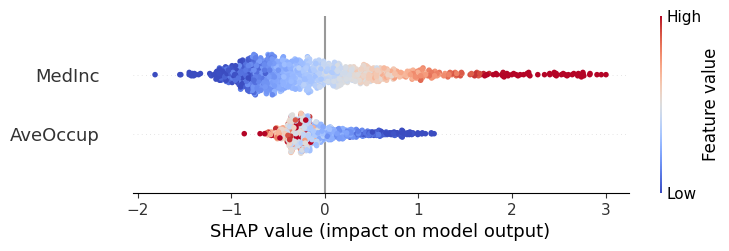

In [242]:
shap.plots.beeswarm(shap_values_f,color=plt.get_cmap('coolwarm'))

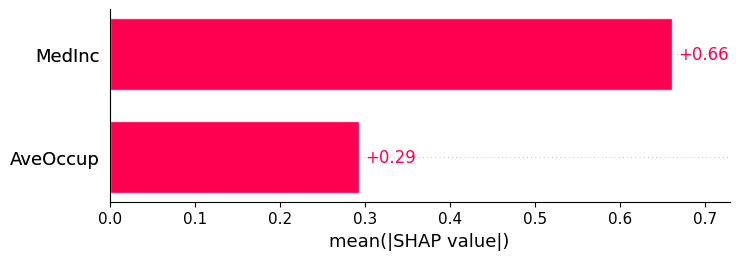

In [267]:
shap.plots.bar(shap_values_f)#,color=plt.get_cmap('coolwarm'))

In [262]:


X_PA_6 = X_train[['HouseAge','AveRooms','AveBedrms','Longitude']]
X_PA_6['MedHousval'] = y_train

X100_PA_6 = X100[['HouseAge','AveRooms','AveBedrms','Longitude']]
X100_PA_6['MedHousval'] = df_test.iloc[:100,-1]
model_diff_6 = diff_model(diffusion_model=loaded_scm[6][0],node=6,info=info)

explainer_f_6 = shap.Explainer(model_diff_6.predict, X100_PA_6)
shap_values_f_6 = explainer_f_6(X_PA_6)

/tmp/ipykernel_1870/749804625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_PA_6['MedHousval'] = y_train
/tmp/ipykernel_1870/749804625.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X100_PA_6['MedHousval'] = df_test.iloc[:100,-1]
ExactExplainer explainer: 1001it [16:37,  1.01s/it]                          


In [332]:
shap_values_f_6.abs.mean(0)

.values =
array([0.07856816, 0.14504967, 0.04279468, 1.85208433, 0.3987582 ])

.base_values =
np.float64(35.657126669158934)

.data =
array([ 28.623     ,   5.32600842,   1.07984938, 119.62495   ,
         2.06442047])

In [359]:
shap.plots.colors.red_rgb*255

array([255.        ,   0.        ,  81.08083606])

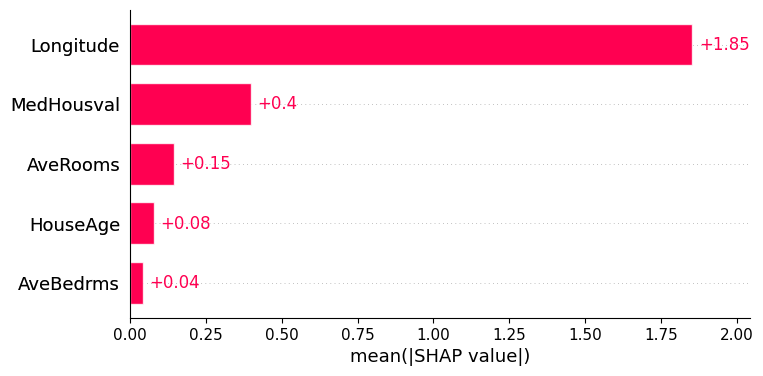

In [275]:
shap.plots.bar(shap_values_f_6.abs.mean(0))

In [345]:
df_shap_f = pd.DataFrame(shap_values_f.abs.values.mean(0),columns=['mean(|SHAP value|)'])
df_shap_f['feature'] = ['MedInc','AveOccup']

df_shap_6 = pd.DataFrame(shap_values_f_6.abs.values.mean(0),columns=['mean(|SHAP value|)'])
df_shap_6['feature'] = ['HouseAge','AveRooms','AveBedrms','Longitude','MedHousVal']

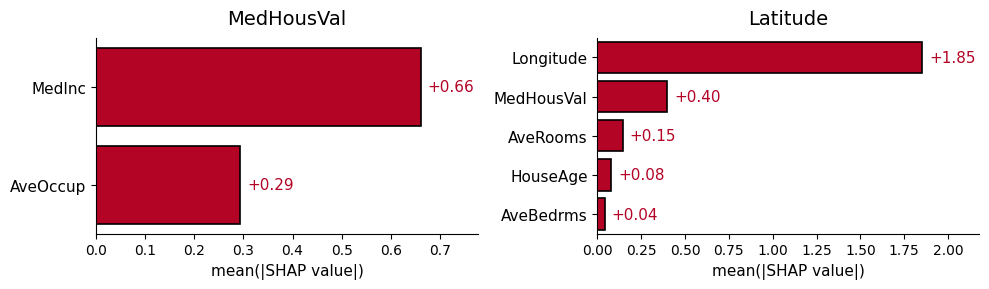

In [437]:
import seaborn as sns
#shapred = #ff0051

fig ,ax = plt.subplots(1,2,figsize=(10,3))

sns.barplot(data=df_shap_f,y='feature',x='mean(|SHAP value|)',orient='h',errorbar=None,ax=ax[0],color='#b40426',saturation=1,edgecolor='black',linewidth=1.2)
sns.barplot(data=df_shap_6,y='feature',x='mean(|SHAP value|)',orient='h',errorbar=None,ax=ax[1],color='#b40426',order=df_shap_6.sort_values('mean(|SHAP value|)',ascending=False).feature,saturation=1,edgecolor='black',linewidth=1.2)

ax[0].bar_label(ax[0].containers[0], fontsize=11,c='#b40426',fmt='+%.2f',padding=5);
ax[0].set_xlim(right=ax[0].get_xlim()[1] * 1.12)

ax[1].bar_label(ax[1].containers[0], fontsize=11,c='#b40426',fmt='+%.2f',padding=5);
ax[1].set_xlim(right=ax[1].get_xlim()[1] * 1.12)


for a in ax:
    # 1. Bold the Y-axis feature names
    for label in a.get_yticklabels():
        #label.set_fontweight(600)
        label.set_fontsize(11)
        label.set_color('black') # Darker gray for a professional look
    # for label in a.get_xticklabels():
    #     label.set_fontsize(13)
    #     label.set_color('black')

    sns.despine(ax=a)

ax[0].set_ylabel('')
ax[1].set_ylabel('')

ax[0].set_xlabel('mean(|SHAP value|)', fontsize=11,color='black' )
ax[1].set_xlabel('mean(|SHAP value|)', fontsize=11,color='black')

ax[0].set_title("MedHousVal", pad=10,fontsize=14)
ax[1].set_title("Latitude", pad=10,fontsize=14)

fig.tight_layout()

fig.savefig('SHAP_TABSCM.pdf',bbox_inches='tight')

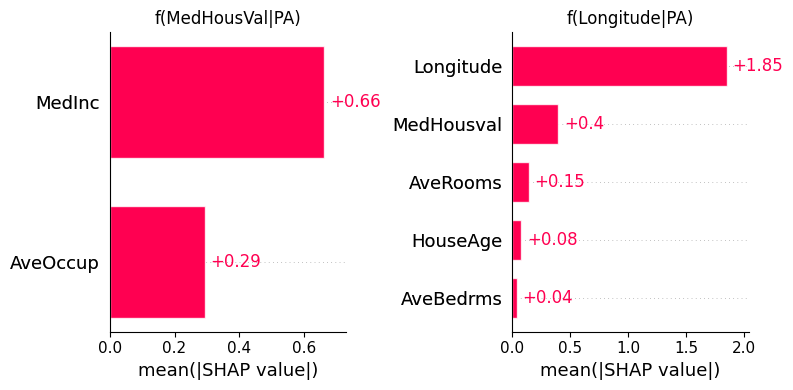

In [295]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Initialize the figure
fig, ax = plt.subplots(1, 2, figsize=(2, 1))


plt.sca(ax[0]) # Set 
shap.plots.bar(shap_values_f,show=False)
plt.title("f(MedHousVal|PA)")

plt.sca(ax[1]) # Set 
shap.plots.bar(shap_values_f_6,show=False)
plt.title("f(Longitude|PA)")

# 4. Final touches
plt.tight_layout()
plt.show()

In [212]:
import seaborn as sns

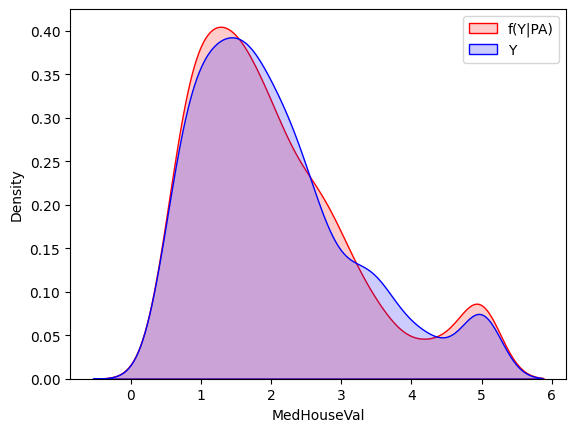

In [225]:
sns.kdeplot(predictions,alpha=0.2,label='f(Y|PA)',color='red',fill=True)
sns.kdeplot(y_train,alpha=0.2,label='Y',color='blue',fill=True)
plt.legend()

In [17]:
COLS = [
        "MedInc",
        "HouseAge",
        "AveRooms",
        "AveBedrms",
        "Population",
        "AveOccup",
        "Latitude",
        "Longitude",
        "MedHouseVal"
    ]

for i,c in enumerate(COLS):
    print(i,c)

PAs = [0,5]
Desc = [1,2,6,7]

print([COLS[pa] for pa in PAs])

[COLS[d] for d in Desc]


0 MedInc
1 HouseAge
2 AveRooms
3 AveBedrms
4 Population
5 AveOccup
6 Latitude
7 Longitude
8 MedHouseVal
['MedInc', 'AveOccup']


['HouseAge', 'AveRooms', 'Latitude', 'Longitude']

In [18]:
# fit a GAM model to the data
import interpret.glassbox

model_ebm = interpret.glassbox.ExplainableBoostingRegressor(interactions=0)
model_ebm.fit(X_train, y_train)

# explain the GAM model with SHAP
explainer_ebm = shap.Explainer(model_ebm.predict, X100)
shap_values_ebm = explainer_ebm(X_train)


ExactExplainer explainer: 1001it [00:11, 11.14it/s]                          


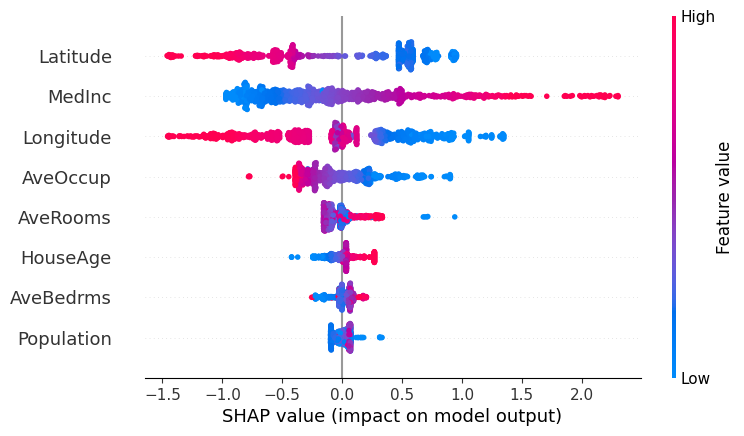

In [19]:
shap.plots.beeswarm(shap_values_ebm)

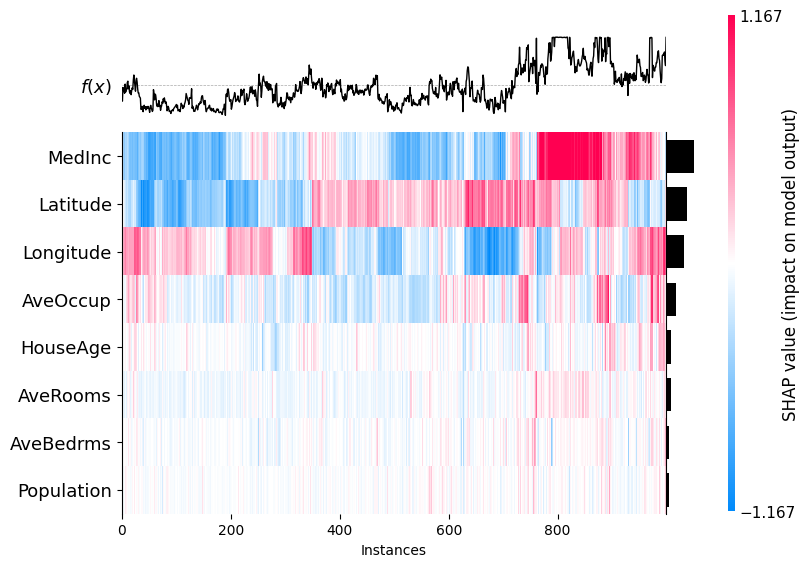

<Axes: xlabel='Instances'>

In [20]:
shap.plots.heatmap(shap_values)

In [53]:
COLS = [
        "age",
        "workclass",
        "fnlwgt",
        "education",
        "education.num",
        "marital.status",
        "occupation",
        "relationship",
        "race",
        "sex",
        "capital.gain",
        "capital.loss",
        "hours.per.week",
        "native.country",
        "income"
]

for i,col in enumerate(COLS):
    print(i,col)

0 age
1 workclass
2 fnlwgt
3 education
4 education.num
5 marital.status
6 occupation
7 relationship
8 race
9 sex
10 capital.gain
11 capital.loss
12 hours.per.week
13 native.country
14 income


In [21]:
df_train_adult = pd.read_csv("../data/adult/train.csv")
df_test_adult = pd.read_csv("../data/adult/test.csv")

X_train_adult = df_train_adult.iloc[:1000,:-1]
#X_train = normalize(X_train)
y_train_adult = df_train_adult.iloc[:1000,-1]

X100 = df_test_adult.iloc[:100,:-1]
#X100 = normalize(X100)


model_adult = xgboost.XGBRegressor()
model.fit(X_train_adult, y_train_adult)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:workclass: object, education: object, marital.status: object, occupation: object, relationship: object, race: object, sex: object, native.country: object

In [87]:
df_train_adult = pd.read_csv("../data/adult/train.csv")
df_test_adult = pd.read_csv("../data/adult/test.csv")

X_train_adult = df_train_adult.iloc[:,:-1]
#X_train = normalize(X_train)
y_train_adult = df_train_adult.iloc[:,-1]

X100 = df_test_adult#.iloc[:100,:-1]
#X100 = normalize(X100)

Cat_cols = [1,3,5,6,7,8,9,13]
ENCODER = {}
for col in Cat_cols:
    print(col)
    ENCODER[col] = sklearn.preprocessing.LabelEncoder()

    ENCODER[col].fit(X_train_adult.iloc[:,col])

    X_train_adult.iloc[:,col] = ENCODER[col].transform(X_train_adult.iloc[:,col])
    X_train_adult.iloc[:,col] = X_train_adult.iloc[:,col].astype('int')

    X100.iloc[:,col] = ENCODER[col].transform(X100.iloc[:,col]).astype('int')


y_train_adult = sklearn.preprocessing.LabelEncoder().fit_transform(y_train_adult).astype('int')

DTYPES = {}
for col,v in enumerate(X_train_adult.dtypes.index.values):
    if col in [1,3,5,6,7,8,9,13]:
        DTYPES[v] = 'int'
    else:
        DTYPES[v] = 'float64'


X_train_adult = X_train_adult.astype(DTYPES)

#drop fnwgt, education redundant
X_train_adult = X_train_adult.drop(columns=['education','fnlwgt'])

X100 = X100.astype(DTYPES).iloc[:,:-1]

X100 = X100.drop(columns=['education','fnlwgt'])


model_adult = xgboost.XGBClassifier()
model_adult.fit(X_train_adult, y_train_adult)


1
3
5
6
7
8
9
13


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [102]:
# compute the SHAP values for the linear model
X_adult, y_adult = shap.datasets.adult()

background_adult = shap.maskers.Independent(X_adult, max_samples=100)
#explainer = shap.Explainer(model_adult.predict, background_adult)
#shap_values = explainer(X_train_adult.iloc[1000:2000,:])

# train XGBoost model
model = xgboost.XGBClassifier(n_estimators=100, max_depth=2).fit(X_adult, y_adult * 1)

# compute SHAP values
explainer = shap.Explainer(model.predict, background_adult)
shap_values = explainer(X_adult)

# set a display version of the data to use for plotting (has string values)
shap_values.display_data = shap.datasets.adult(display=True)[0].values

PermutationExplainer explainer: 32562it [33:21, 16.17it/s]                             


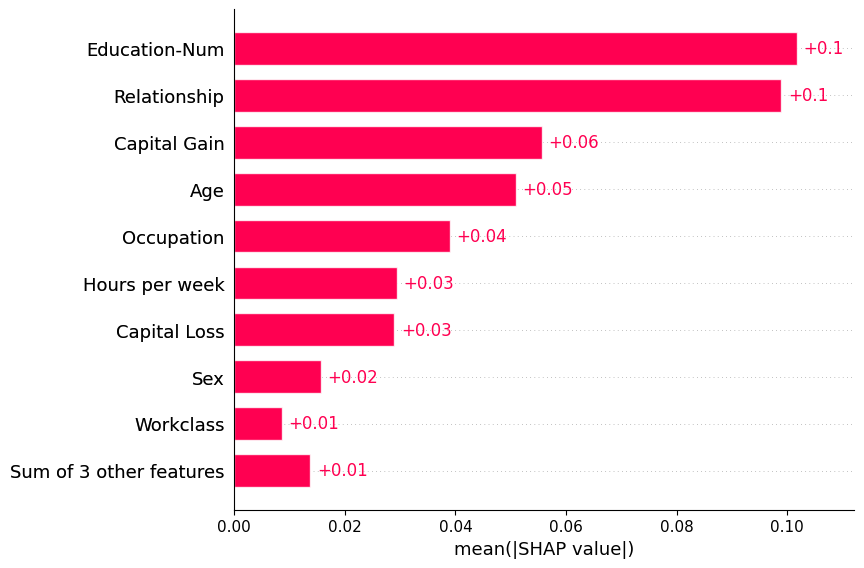

In [109]:
shap.plots.bar(shap_values)

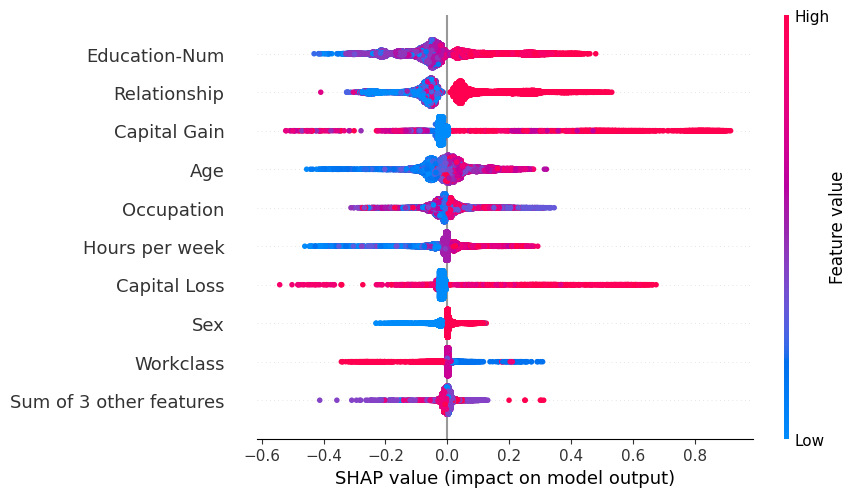

In [110]:
shap.plots.beeswarm(shap_values)

In [92]:
X_adult, y_adult = shap.datasets.adult()


X_adult.describe()

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581646,3.868892,10.080679,2.611836,6.572740,2.494518,3.665858,0.669205,1077.648804,87.303833,40.437454,36.718866
std,13.640432,1.455960,2.572720,1.506222,4.228857,1.758232,0.848806,0.470506,7385.291992,402.960205,12.347429,7.823782
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,4.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,0.000000,40.000000,39.000000
50%,37.000000,4.000000,10.000000,2.000000,7.000000,3.000000,4.000000,1.000000,0.000000,0.000000,40.000000,39.000000
75%,48.000000,4.000000,12.000000,4.000000,10.000000,4.000000,4.000000,1.000000,0.000000,0.000000,45.000000,39.000000
max,90.000000,8.000000,16.000000,6.000000,14.000000,5.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,41.000000


In [93]:
X_train_adult.describe()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,3.868892,10.080679,2.611836,6.572740,1.446362,3.665858,0.669205,1077.648844,87.303830,40.437456,36.718866
std,13.640433,1.455960,2.572720,1.506222,4.228857,1.606771,0.848806,0.470506,7385.292085,402.960219,12.347429,7.823782
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,4.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,0.000000,40.000000,39.000000
50%,37.000000,4.000000,10.000000,2.000000,7.000000,1.000000,4.000000,1.000000,0.000000,0.000000,40.000000,39.000000
75%,48.000000,4.000000,12.000000,4.000000,10.000000,3.000000,4.000000,1.000000,0.000000,0.000000,45.000000,39.000000
max,90.000000,8.000000,16.000000,6.000000,14.000000,5.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,41.000000


<Axes: >

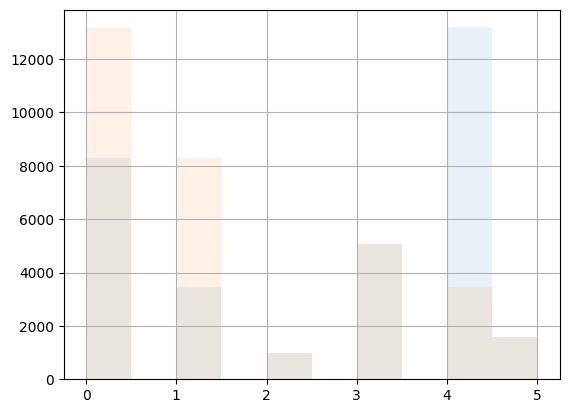

In [97]:
X_adult['Relationship'].hist(alpha=0.1)
X_train_adult['relationship'].hist(alpha=0.1)